# Improving the 2D fluid simulation with fourier transforms

# 2D Fluid Simulation Using Fourier Transforms

This notebook simulates 2D fluid flow using spectral methods. We use Fourier transforms to compute spatial derivatives efficiently and apply a semi-implicit scheme to allow larger viscosities and time steps.

---

## 1. Governing Equation (Real Space)

We begin with the 2D **viscous Burgers’ equation** for a scalar field $ u(x, y, t) $:

$$
\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} + u \frac{\partial u}{\partial y} = \nu \left( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right)
$$

Or, more compactly:

$$
\frac{\partial u}{\partial t} + u \nabla u = \nu \nabla^2 u
$$

This equation contains nonlinear advection and linear diffusion.

---

## 2. Derivatives in Fourier Space

Let $ \hat{u}(k_x, k_y, t) $ denote the 2D Fourier transform of $ u(x, y, t) $. Spatial derivatives in Fourier space become algebraic:

- First derivatives:

$$
\mathcal{F}\left[ \frac{\partial u}{\partial x} \right] = i k_x \hat{u}, \quad
\mathcal{F}\left[ \frac{\partial u}{\partial y} \right] = i k_y \hat{u}
$$

- Laplacian:

$$
\mathcal{F}\left[ \nabla^2 u \right] = - (k_x^2 + k_y^2) \hat{u}
$$

---

## 3. Time-Stepping with a Semi-Implicit Scheme

We update the solution using a semi-implicit scheme:

1. **We compute the nonlinear term in real space**:

$$
N(u) = u \frac{\partial u}{\partial x} + u \frac{\partial u}{\partial y}
$$

2. **Then transform the nonlinear term to Fourier space**:

$$
\hat{N}(k_x, k_y) = \mathcal{F}[N(u)]
$$

3. **And update the field in spectral space**:

$$
\hat{u}^{n+1} = \frac{ \hat{u}^n - \Delta t \cdot \hat{N}^n }{1 + \nu \Delta t (k_x^2 + k_y^2)}
$$

This step allows large time steps $ \Delta t $ even for high viscosity $ \nu $.

---

## 4. Enforcing Incompressibility (for Vector Fields)

For vector velocity fields $ \mathbf{u} = (u_x, u_y) $, we need to ensure **incompressibility**:

$$
\nabla \cdot \mathbf{u} = 0
$$

This is enforced using a **projection step** involving a scalar pressure field $ p(x, y, t) $.

---

### Intermediate Velocity Update

Advance the velocity using advection and diffusion to get an intermediate velocity $ \mathbf{u}^* $:

$$
\frac{\mathbf{u}^* - \mathbf{u}^n}{\Delta t} = - (\mathbf{u} \cdot \nabla) \mathbf{u} + \nu \nabla^2 \mathbf{u}
$$

This $ \mathbf{u}^* $ may **not** be divergence-free.

---

### Pressure Projection

We enforce incompressibility by subtracting the gradient of pressure:

$$
\mathbf{u}^{n+1} = \mathbf{u}^* - \Delta t \nabla p
$$

Take divergence of both sides:

$$
\nabla \cdot \mathbf{u}^{n+1} = \nabla \cdot \mathbf{u}^* - \Delta t \nabla^2 p = 0
$$

So we solve the **Poisson equation for pressure**:

$$
\nabla^2 p = \frac{1}{\Delta t} \nabla \cdot \mathbf{u}^*
$$

---

### Solving in Fourier Space

Take the Fourier transform of the pressure equation:

$$
- (k_x^2 + k_y^2) \hat{p} = \frac{1}{\Delta t} (i k_x \hat{u}_x^* + i k_y \hat{u}_y^*)
$$

Solving for $ \hat{p} $:

$$
\hat{p} = \frac{i k_x \hat{u}_x^* + i k_y \hat{u}_y^*}{k_x^2 + k_y^2}
$$

To avoid division by zero, set:

$$
\hat{p}(0, 0) = 0
$$

---

### Final Velocity Update

Now correct the intermediate velocity to be divergence-free:

$$
\hat{u}_x^{n+1} = \hat{u}_x^* - i k_x \Delta t \hat{p}
$$

$$
\hat{u}_y^{n+1} = \hat{u}_y^* - i k_y \Delta t \hat{p}
$$

This yields a velocity field $ \mathbf{u}^{n+1} $ that satisfies $ \nabla \cdot \mathbf{u}^{n+1} = 0 $.

---


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

In [ ]:
nx, ny = 256, 256
Lx, Ly = 2 * np.pi, 2 * np.pi

dx = Lx / nx
dy = Ly / ny

x = np.linspace(0.0, Lx, nx, endpoint=False)
y = np.linspace(0.0, Ly, ny, endpoint=False)
X, Y = np.meshgrid(x, y, indexing="xy")

# A smooth periodic initial velocity field
u_initial = np.sin(2 * X / Lx) * np.cos(2 * Y / Ly)
v_initial = -np.cos(2 * X / Lx) * np.sin(2 * Y / Ly)

speed_initial = np.sqrt(u_initial**2 + v_initial**2)

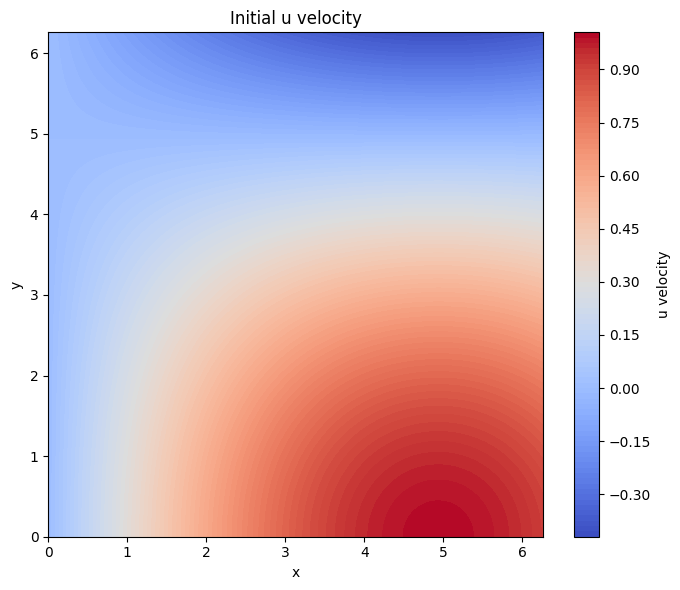

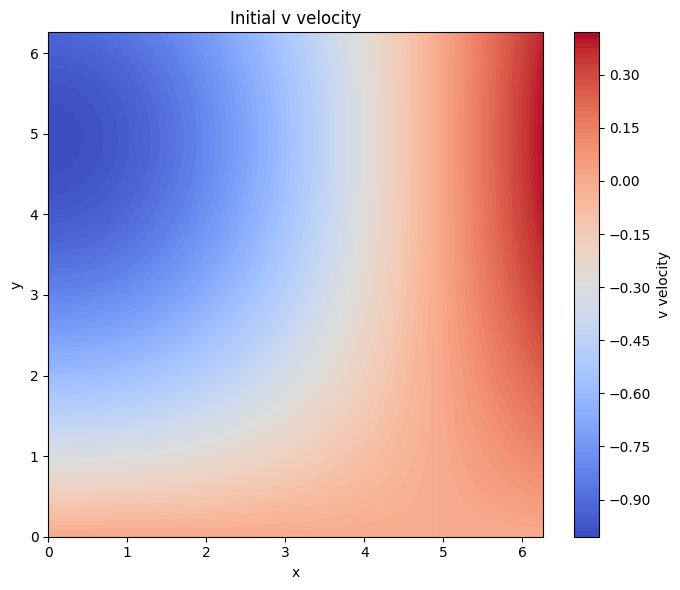

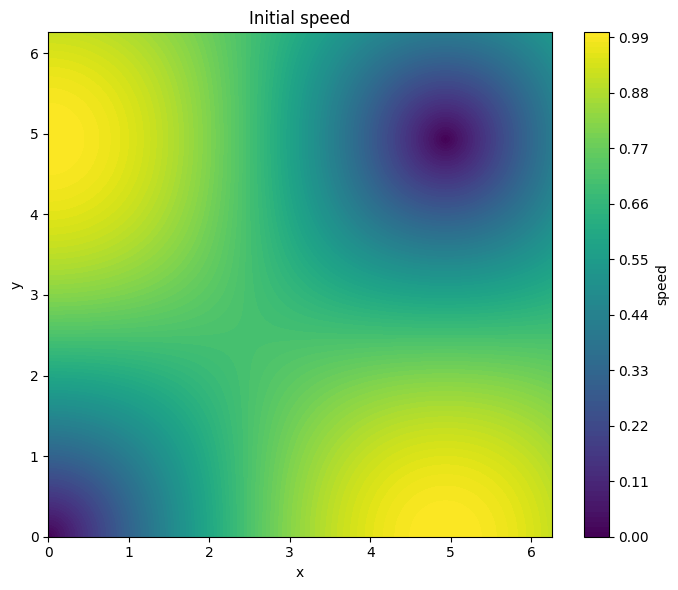

In [ ]:
plt.figure(figsize=(7, 6))
plt.contourf(X, Y, u_initial, levels=100, cmap="coolwarm")
plt.colorbar(label="u velocity")
plt.title("Initial u velocity")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
plt.contourf(X, Y, v_initial, levels=100, cmap="coolwarm")
plt.colorbar(label="v velocity")
plt.title("Initial v velocity")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
plt.contourf(X, Y, speed_initial, levels=100, cmap="viridis")
plt.colorbar(label="speed")
plt.title("Initial speed")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

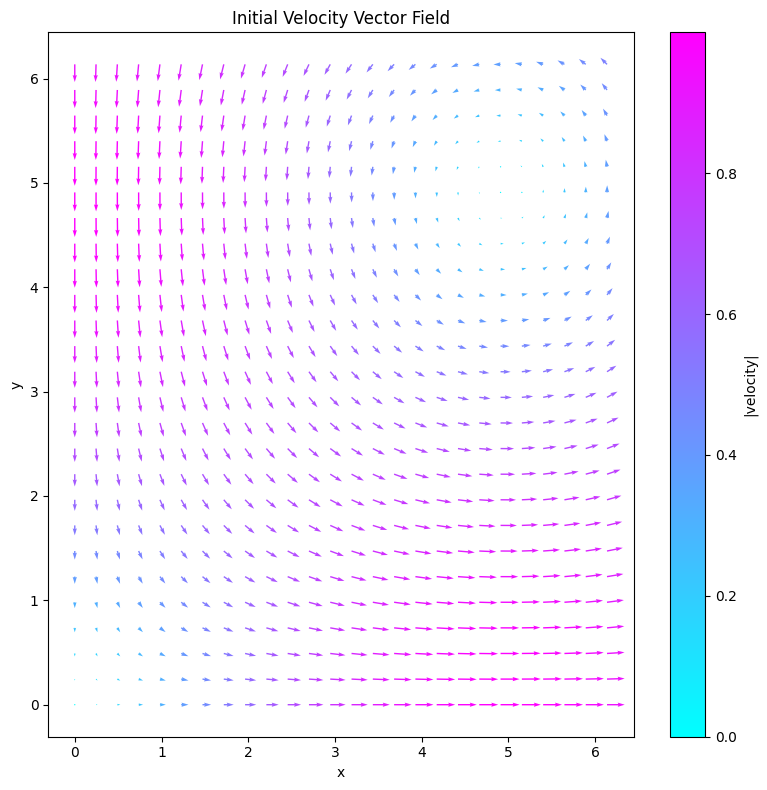

In [ ]:
step = 10

plt.figure(figsize=(8, 8))
plt.quiver(
    X[::step, ::step],
    Y[::step, ::step],
    u_initial[::step, ::step],
    v_initial[::step, ::step],
    speed_initial[::step, ::step],
    cmap="cool",
)
plt.title("Initial Velocity Vector Field")
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar(label="|velocity|")
plt.tight_layout()
plt.show()

# Fourier representation

I work with the vorticity field

$$
\omega = \frac{\partial v}{\partial x} - \frac{\partial u}{\partial y}
$$

and recover the velocity through the streamfunction:

$$
\nabla^2 \psi = -\omega
$$

with

$$
u = \frac{\partial \psi}{\partial y}, \qquad
v = -\frac{\partial \psi}{\partial x}.
$$

In Fourier space:

$$
\hat{\psi} = -\frac{\hat{\omega}}{k_x^2 + k_y^2}
$$

and then

$$
\hat{u} = i k_y \hat{\psi}, \qquad
\hat{v} = -i k_x \hat{\psi}.
$$

Spatial derivatives are also computed spectrally:

$$
\widehat{\omega_x} = i k_x \hat{\omega}, \qquad
\widehat{\omega_y} = i k_y \hat{\omega}.
$$

In [6]:
nu = 0.01
dt = 0.001
nt = 500
save_every = 2

In [7]:
def build_wavenumbers(nx, ny, dx, dy):
    kx = 2.0 * np.pi * np.fft.fftfreq(nx, d=dx)
    ky = 2.0 * np.pi * np.fft.fftfreq(ny, d=dy)
    KX, KY = np.meshgrid(kx, ky, indexing="xy")
    K2 = KX**2 + KY**2
    return KX, KY, K2


def velocity_to_vorticity_hat(u, v, KX, KY):
    u_hat = np.fft.fft2(u)
    v_hat = np.fft.fft2(v)
    omega_hat = 1j * KX * v_hat - 1j * KY * u_hat
    return omega_hat


def streamfunction_hat_from_vorticity_hat(omega_hat, K2):
    K2_safe = K2.copy()
    K2_safe[0, 0] = 1.0

    psi_hat = -omega_hat / K2_safe
    psi_hat[0, 0] = 0.0
    return psi_hat


def velocity_from_vorticity_hat(omega_hat, KX, KY, K2):
    psi_hat = streamfunction_hat_from_vorticity_hat(omega_hat, K2)

    u_hat = 1j * KY * psi_hat
    v_hat = -1j * KX * psi_hat

    u = np.fft.ifft2(u_hat).real
    v = np.fft.ifft2(v_hat).real
    return u, v


def spectral_gradients_from_vorticity_hat(omega_hat, KX, KY):
    d_omega_dx = np.fft.ifft2(1j * KX * omega_hat).real
    d_omega_dy = np.fft.ifft2(1j * KY * omega_hat).real
    return d_omega_dx, d_omega_dy

In [9]:
## One step fourier solver

def fourier_vorticity_step(omega_hat, KX, KY, K2, nu, dt):
    """
    Advance the vorticity by one time step using a semi-implicit scheme:
    - nonlinear term explicit
    - diffusion term implicit
    """
    u, v = velocity_from_vorticity_hat(omega_hat, KX, KY, K2)
    d_omega_dx, d_omega_dy = spectral_gradients_from_vorticity_hat(omega_hat, KX, KY)

    nonlinear = u * d_omega_dx + v * d_omega_dy
    nonlinear_hat = np.fft.fft2(nonlinear)

    omega_hat_new = (omega_hat - dt * nonlinear_hat) / (1.0 + dt * nu * K2)
    omega_hat_new[0, 0] = omega_hat[0, 0]

    return omega_hat_new

In [10]:
## Some cool assertions
def compute_divergence_spectral(u, v, KX, KY):
    u_hat = np.fft.fft2(u)
    v_hat = np.fft.fft2(v)
    div = np.fft.ifft2(1j * KX * u_hat + 1j * KY * v_hat).real
    return div


def compute_kinetic_energy(u, v, dx, dy):
    return 0.5 * np.sum(u**2 + v**2) * dx * dy


def compute_enstrophy(omega, dx, dy):
    return 0.5 * np.sum(omega**2) * dx * dy


def compute_circulation(omega, dx, dy):
    return np.sum(omega) * dx * dy

In [11]:
KX, KY, K2 = build_wavenumbers(nx, ny, dx, dy)
omega_hat = velocity_to_vorticity_hat(u_initial, v_initial, KX, KY)

omega_frames = []
u_frames = []
v_frames = []
speed_frames = []

audit = {
    "step": [],
    "kinetic_energy": [],
    "enstrophy": [],
    "circulation": [],
    "mean_vorticity": [],
    "max_abs_divergence": [],
    "max_speed": [],
}

for n in range(nt):
    omega_hat = fourier_vorticity_step(omega_hat, KX, KY, K2, nu, dt)

    u, v = velocity_from_vorticity_hat(omega_hat, KX, KY, K2)
    omega = np.fft.ifft2(omega_hat).real
    speed = np.sqrt(u**2 + v**2)
    div = compute_divergence_spectral(u, v, KX, KY)

    audit["step"].append(n + 1)
    audit["kinetic_energy"].append(compute_kinetic_energy(u, v, dx, dy))
    audit["enstrophy"].append(compute_enstrophy(omega, dx, dy))
    audit["circulation"].append(compute_circulation(omega, dx, dy))
    audit["mean_vorticity"].append(np.mean(omega))
    audit["max_abs_divergence"].append(np.max(np.abs(div)))
    audit["max_speed"].append(np.max(speed))

    if n % save_every == 0:
        omega_frames.append(omega.copy())
        u_frames.append(u.copy())
        v_frames.append(v.copy())
        speed_frames.append(speed.copy())

omega_final = np.fft.ifft2(omega_hat).real
u_final, v_final = velocity_from_vorticity_hat(omega_hat, KX, KY, K2)

In [12]:
def audit_fourier_solution(omega_hat, KX, KY, K2, dx, dy, audit, nu, divergence_tol=1e-9, mean_tol=1e-10):
    omega = np.fft.ifft2(omega_hat).real
    u, v = velocity_from_vorticity_hat(omega_hat, KX, KY, K2)
    div = compute_divergence_spectral(u, v, KX, KY)

    assert np.isfinite(omega).all(), "omega contains NaN or inf"
    assert np.isfinite(u).all(), "u contains NaN or inf"
    assert np.isfinite(v).all(), "v contains NaN or inf"

    assert np.max(np.abs(div)) < divergence_tol, "divergence is too large"

    mean_vorticity_initial = audit["mean_vorticity"][0]
    mean_vorticity_final = audit["mean_vorticity"][-1]
    assert abs(mean_vorticity_final - mean_vorticity_initial) < mean_tol, "mean vorticity drifted too much"

    if nu > 0.0:
        energy_initial = audit["kinetic_energy"][0]
        energy_final = audit["kinetic_energy"][-1]
        assert energy_final <= energy_initial + 1e-10, "kinetic energy grew even though viscosity is positive"

    print("Audit passed.")
    print(f"max |divergence| = {np.max(np.abs(div)):.3e}")
    print(f"initial energy   = {audit['kinetic_energy'][0]:.6e}")
    print(f"final energy     = {audit['kinetic_energy'][-1]:.6e}")
    print(f"initial enstrophy= {audit['enstrophy'][0]:.6e}")
    print(f"final enstrophy  = {audit['enstrophy'][-1]:.6e}")


audit_fourier_solution(omega_hat, KX, KY, K2, dx, dy, audit, nu)

Audit passed.
max |divergence| = 3.584e-14
initial energy   = 4.344345e+00
final energy     = 3.936022e+00
initial enstrophy= 3.683659e+02
final enstrophy  = 2.076295e+01


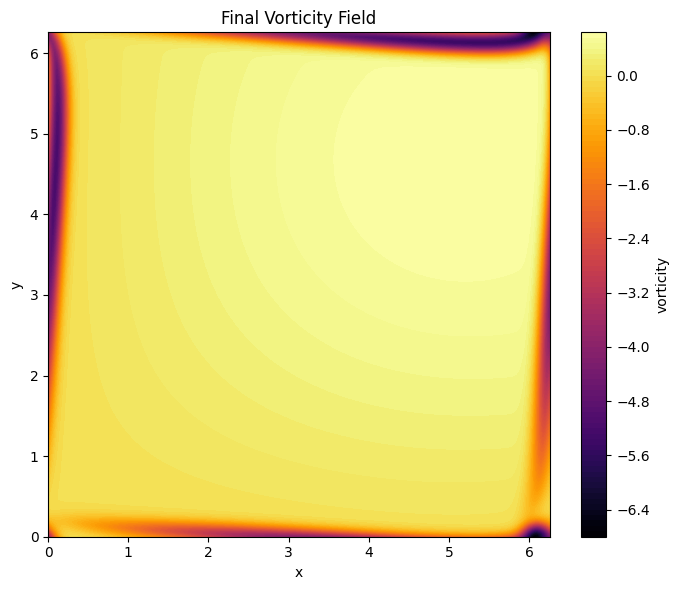

In [13]:
plt.figure(figsize=(7, 6))
plt.contourf(X, Y, omega_final, levels=100, cmap="inferno")
plt.colorbar(label="vorticity")
plt.title("Final Vorticity Field")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

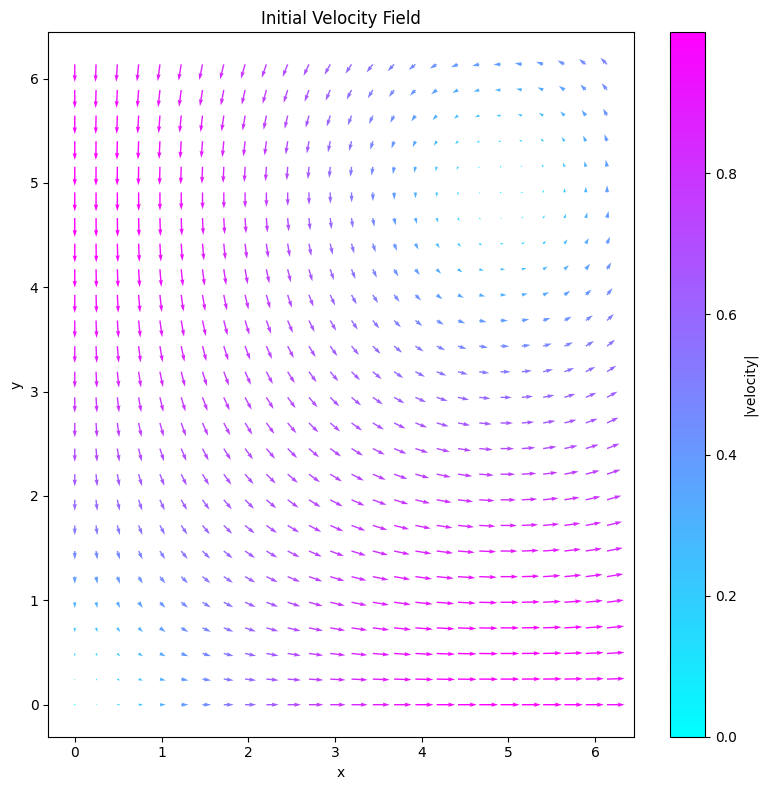

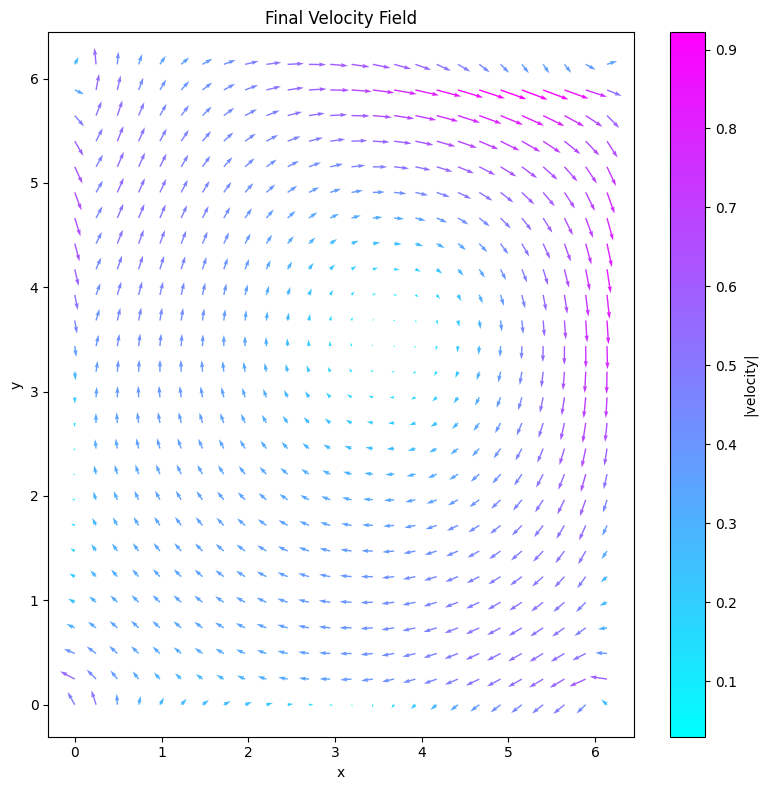

In [14]:
def plot_velocity_field(X, Y, u, v, step=10, title="Velocity Field"):
    speed = np.sqrt(u**2 + v**2)

    plt.figure(figsize=(8, 8))
    plt.quiver(
        X[::step, ::step],
        Y[::step, ::step],
        u[::step, ::step],
        v[::step, ::step],
        speed[::step, ::step],
        cmap="cool",
    )
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.colorbar(label="|velocity|")
    plt.tight_layout()
    plt.show()


plot_velocity_field(X, Y, u_initial, v_initial, step=10, title="Initial Velocity Field")
plot_velocity_field(X, Y, u_final, v_final, step=10, title="Final Velocity Field")

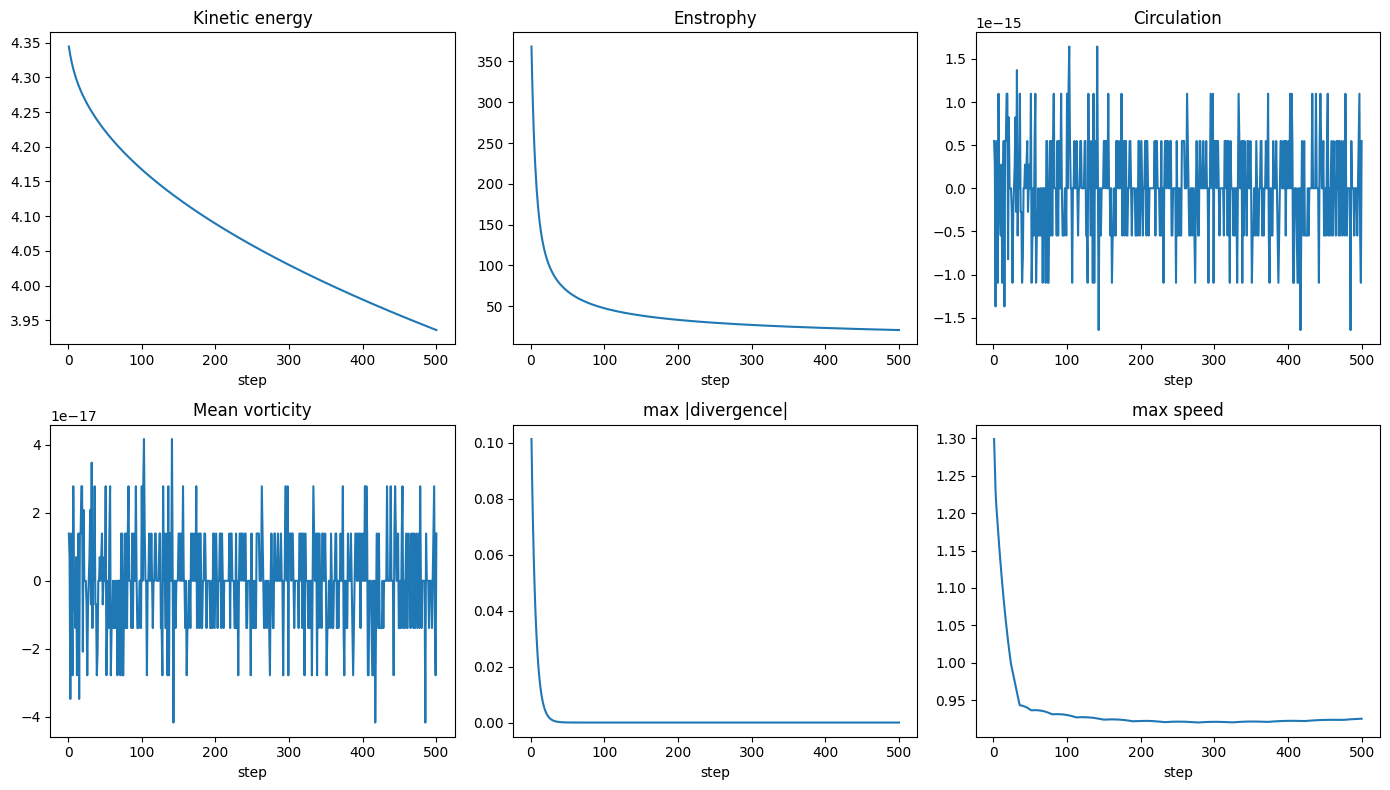

In [15]:
def plot_audit(audit):
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))

    axes[0, 0].plot(audit["step"], audit["kinetic_energy"])
    axes[0, 0].set_title("Kinetic energy")
    axes[0, 0].set_xlabel("step")

    axes[0, 1].plot(audit["step"], audit["enstrophy"])
    axes[0, 1].set_title("Enstrophy")
    axes[0, 1].set_xlabel("step")

    axes[0, 2].plot(audit["step"], audit["circulation"])
    axes[0, 2].set_title("Circulation")
    axes[0, 2].set_xlabel("step")

    axes[1, 0].plot(audit["step"], audit["mean_vorticity"])
    axes[1, 0].set_title("Mean vorticity")
    axes[1, 0].set_xlabel("step")

    axes[1, 1].plot(audit["step"], audit["max_abs_divergence"])
    axes[1, 1].set_title("max |divergence|")
    axes[1, 1].set_xlabel("step")

    axes[1, 2].plot(audit["step"], audit["max_speed"])
    axes[1, 2].set_title("max speed")
    axes[1, 2].set_xlabel("step")

    plt.tight_layout()
    plt.show()


plot_audit(audit)

C:\Users\Oscar\AppData\Local\Temp\ipykernel_9960\3570875940.py:16: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  return cont.collections


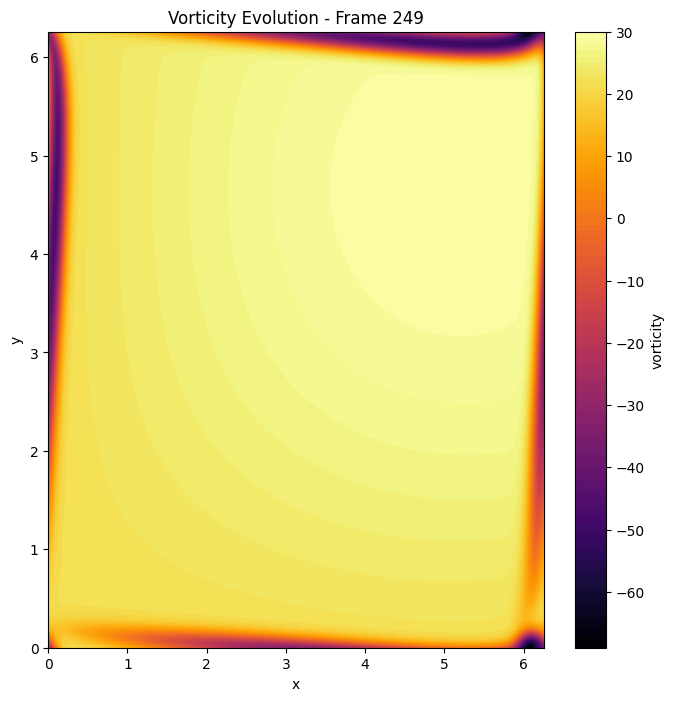

In [16]:
def animate_vorticity(X, Y, omega_frames, interval=50, gif_name=None):
    fig, ax = plt.subplots(figsize=(8, 8))

    contour = ax.contourf(X, Y, omega_frames[0], levels=100, cmap="inferno")
    plt.colorbar(contour, ax=ax, label="vorticity")
    ax.set_title("Vorticity Evolution")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    def update(frame):
        ax.clear()
        cont = ax.contourf(X, Y, omega_frames[frame], levels=100, cmap="inferno")
        ax.set_title(f"Vorticity Evolution - Frame {frame}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        return cont.collections

    ani = FuncAnimation(fig, update, frames=len(omega_frames), interval=interval, blit=False)

    if gif_name is not None:
        ani.save(gif_name, writer=PillowWriter(fps=max(1, int(1000 / interval))))

    plt.show()
    return ani


ani = animate_vorticity(X, Y, omega_frames, interval=50, gif_name="vorticity_evolution.gif")

# Putting everything inside one function

Now that the pieces are built separately, I wrap them into a single function so I can run different periodic flow scenarios more easily.

Since this Fourier solver is periodic, I use periodic initial conditions such as:

- wave
- shear
- vortex lattice
- diagonal wave
- random smooth field

The function will:

- build the grid
- create the selected initial condition
- run the simulation
- audit the result
- plot initial/final states
- plot the diagnostic curves
- animate the vorticity

In [17]:
def run_fourier_fluid_simulation(
    nx=256,
    ny=256,
    Lx=2*np.pi,
    Ly=2*np.pi,
    nu=0.01,
    dt=0.001,
    nt=500,
    init="wave",
    amplitude=1.0,
    save_every=2,
    step_plot=10,
    interval=50,
    save_gif=False,
    gif_name="fourier_vorticity.gif",
    show_initial=True,
    show_final=True,
    show_audit=True,
):
    x = np.linspace(0.0, Lx, nx, endpoint=False)
    y = np.linspace(0.0, Ly, ny, endpoint=False)
    dx = Lx / nx
    dy = Ly / ny
    X, Y = np.meshgrid(x, y, indexing="xy")

    KX, KY, K2 = build_wavenumbers(nx, ny, dx, dy)

    def make_initial_condition(kind, amplitude):
        if kind == "wave":
            u0 = np.sin(2 * X / Lx) * np.cos(2 * Y / Ly)
            v0 = -np.cos(2 * X / Lx) * np.sin(2 * Y / Ly)

        elif kind == "shear":
            u0 = np.sin(2 * np.pi * Y / Ly)
            v0 = 0.2 * np.sin(2 * np.pi * X / Lx)

        elif kind == "vortex_lattice":
            u0 = np.sin(4 * np.pi * Y / Ly)
            v0 = np.sin(4 * np.pi * X / Lx)

        elif kind == "diagonal_wave":
            u0 = np.sin(2 * np.pi * (X + Y) / Lx)
            v0 = -np.sin(2 * np.pi * (X - Y) / Ly)

        elif kind == "random_smooth":
            rng = np.random.default_rng(4)
            omega0 = rng.standard_normal((ny, nx))
            omega0_hat = np.fft.fft2(omega0)

            filter_strength = np.exp(-0.02 * K2)
            omega0_hat *= filter_strength
            omega0_hat[0, 0] = 0.0

            u0, v0 = velocity_from_vorticity_hat(omega0_hat, KX, KY, K2)

        else:
            raise ValueError("init must be one of: wave, shear, vortex_lattice, diagonal_wave, random_smooth")

        speed0 = np.sqrt(u0**2 + v0**2)
        max_speed0 = np.max(speed0)
        if max_speed0 > 0:
            u0 = amplitude * u0 / max_speed0
            v0 = amplitude * v0 / max_speed0

        return u0, v0

    u0, v0 = make_initial_condition(init, amplitude)
    omega_hat = velocity_to_vorticity_hat(u0, v0, KX, KY)

    omega_frames = []
    u_frames = []
    v_frames = []
    speed_frames = []

    audit = {
        "step": [],
        "kinetic_energy": [],
        "enstrophy": [],
        "circulation": [],
        "mean_vorticity": [],
        "max_abs_divergence": [],
        "max_speed": [],
    }

    for n in range(nt):
        omega_hat = fourier_vorticity_step(omega_hat, KX, KY, K2, nu, dt)

        u, v = velocity_from_vorticity_hat(omega_hat, KX, KY, K2)
        omega = np.fft.ifft2(omega_hat).real
        speed = np.sqrt(u**2 + v**2)
        div = compute_divergence_spectral(u, v, KX, KY)

        audit["step"].append(n + 1)
        audit["kinetic_energy"].append(compute_kinetic_energy(u, v, dx, dy))
        audit["enstrophy"].append(compute_enstrophy(omega, dx, dy))
        audit["circulation"].append(compute_circulation(omega, dx, dy))
        audit["mean_vorticity"].append(np.mean(omega))
        audit["max_abs_divergence"].append(np.max(np.abs(div)))
        audit["max_speed"].append(np.max(speed))

        if n % save_every == 0:
            omega_frames.append(omega.copy())
            u_frames.append(u.copy())
            v_frames.append(v.copy())
            speed_frames.append(speed.copy())

    u_final, v_final = velocity_from_vorticity_hat(omega_hat, KX, KY, K2)
    omega_final = np.fft.ifft2(omega_hat).real

    audit_fourier_solution(omega_hat, KX, KY, K2, dx, dy, audit, nu)

    if show_initial:
        plot_velocity_field(X, Y, u0, v0, step=step_plot, title=f"Initial Velocity Field ({init})")

        plt.figure(figsize=(7, 6))
        omega0 = np.fft.ifft2(velocity_to_vorticity_hat(u0, v0, KX, KY)).real
        plt.contourf(X, Y, omega0, levels=100, cmap="inferno")
        plt.colorbar(label="vorticity")
        plt.title(f"Initial Vorticity ({init})")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.tight_layout()
        plt.show()

    if show_final:
        plot_velocity_field(X, Y, u_final, v_final, step=step_plot, title="Final Velocity Field")

        plt.figure(figsize=(7, 6))
        plt.contourf(X, Y, omega_final, levels=100, cmap="inferno")
        plt.colorbar(label="vorticity")
        plt.title("Final Vorticity Field")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.tight_layout()
        plt.show()

    if show_audit:
        plot_audit(audit)

    ani = animate_vorticity(
        X,
        Y,
        omega_frames,
        interval=interval,
        gif_name=gif_name if save_gif else None,
    )

    return {
        "x": x,
        "y": y,
        "X": X,
        "Y": Y,
        "u0": u0,
        "v0": v0,
        "u": u_final,
        "v": v_final,
        "omega": omega_final,
        "omega_hat": omega_hat,
        "u_frames": u_frames,
        "v_frames": v_frames,
        "omega_frames": omega_frames,
        "speed_frames": speed_frames,
        "audit": audit,
        "animation": ani,
    }

Audit passed.
max |divergence| = 3.474e-14
initial energy   = 4.344346e+00
final energy     = 3.765669e+00
initial enstrophy= 3.683660e+02
final enstrophy  = 1.443041e+01


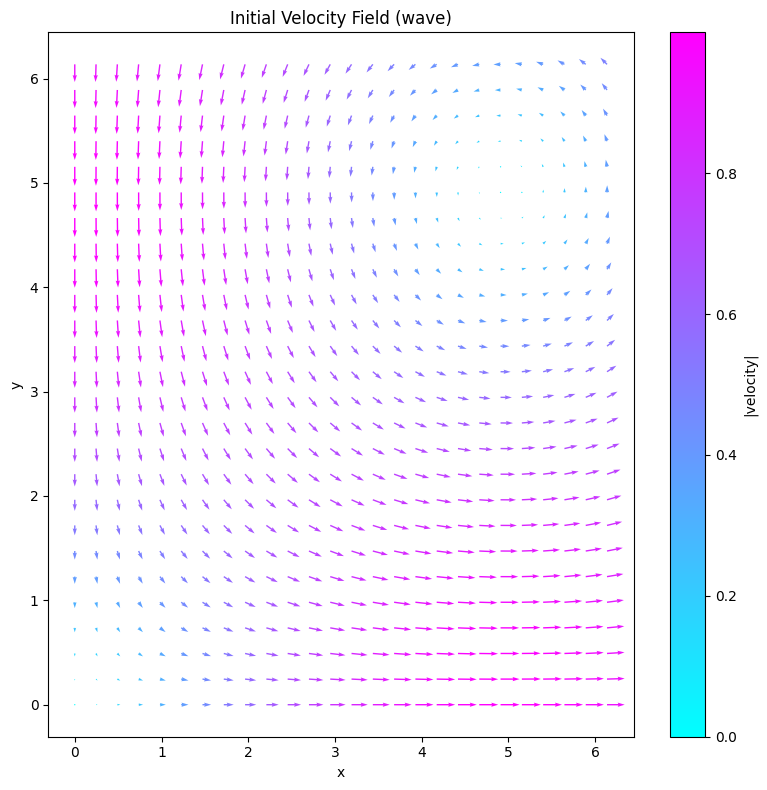

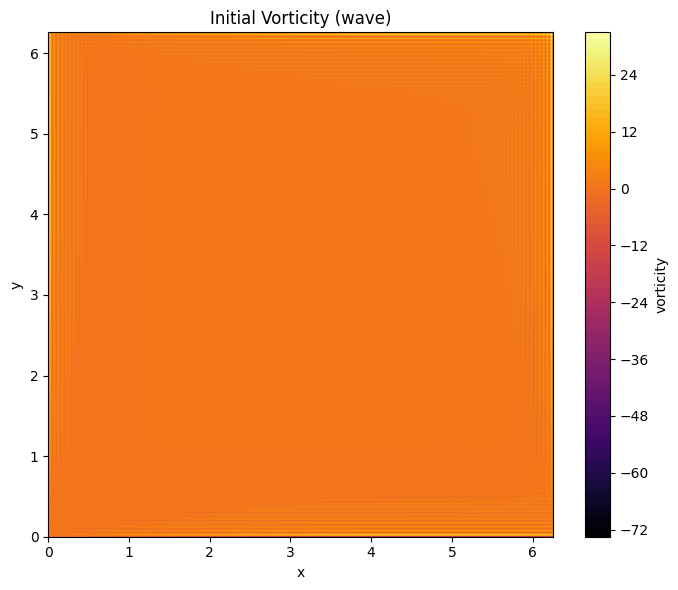

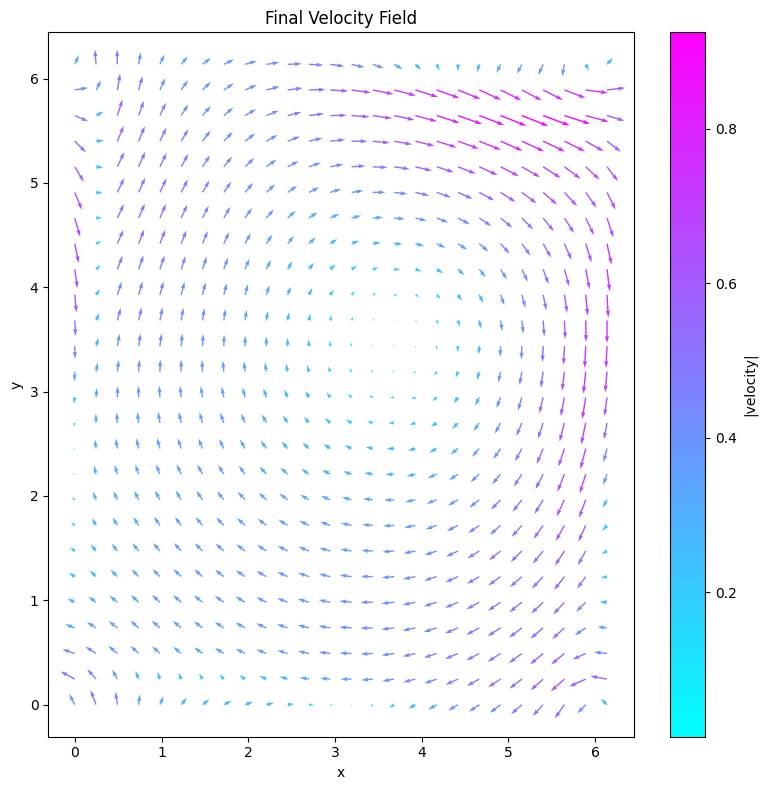

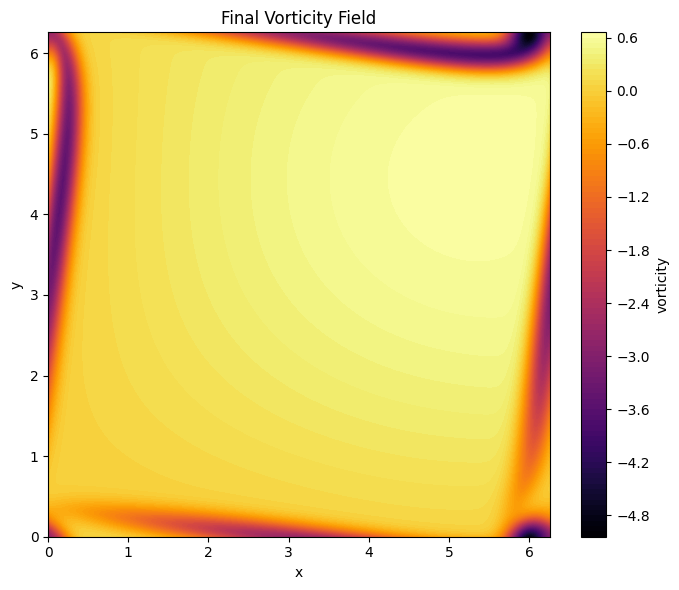

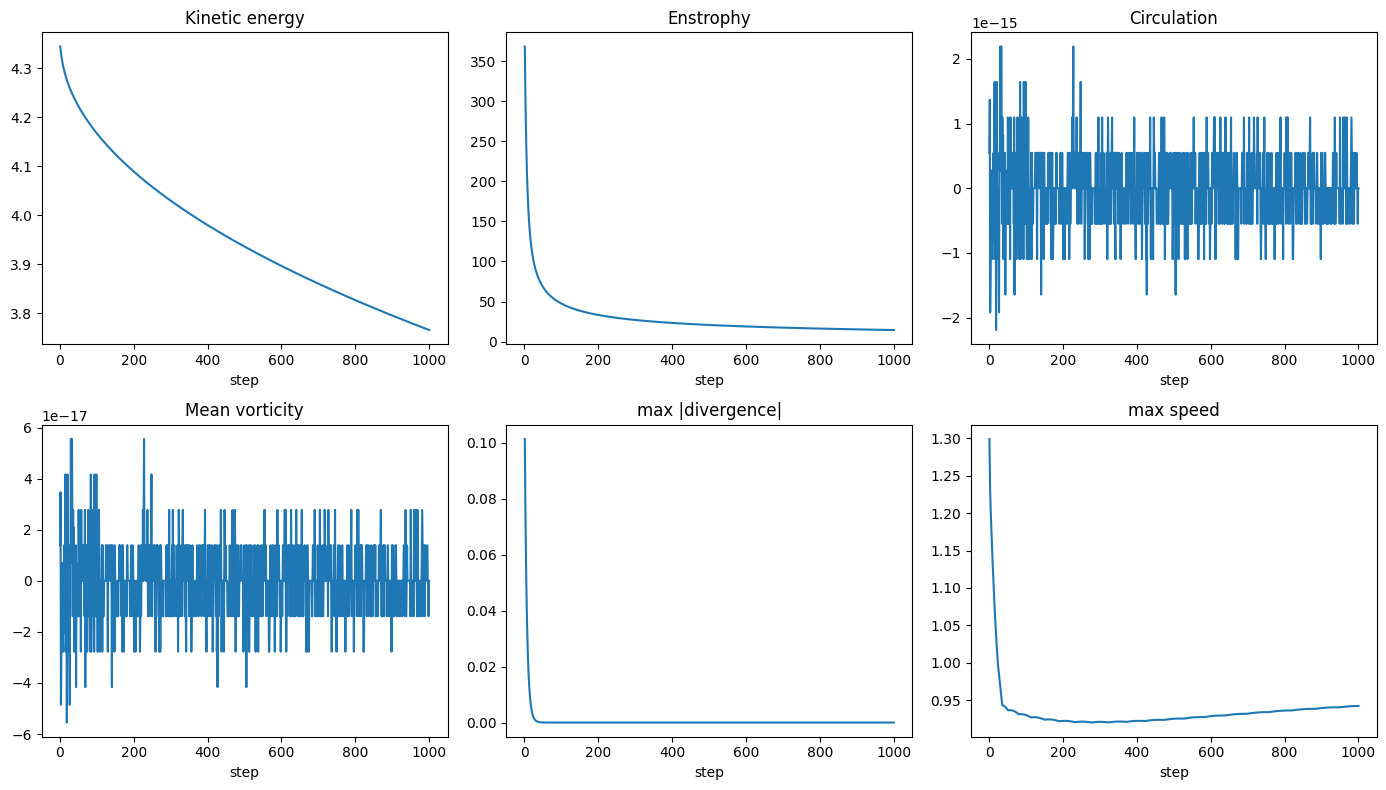

C:\Users\Oscar\AppData\Local\Temp\ipykernel_9960\3570875940.py:16: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  return cont.collections


ValueError: quantization error

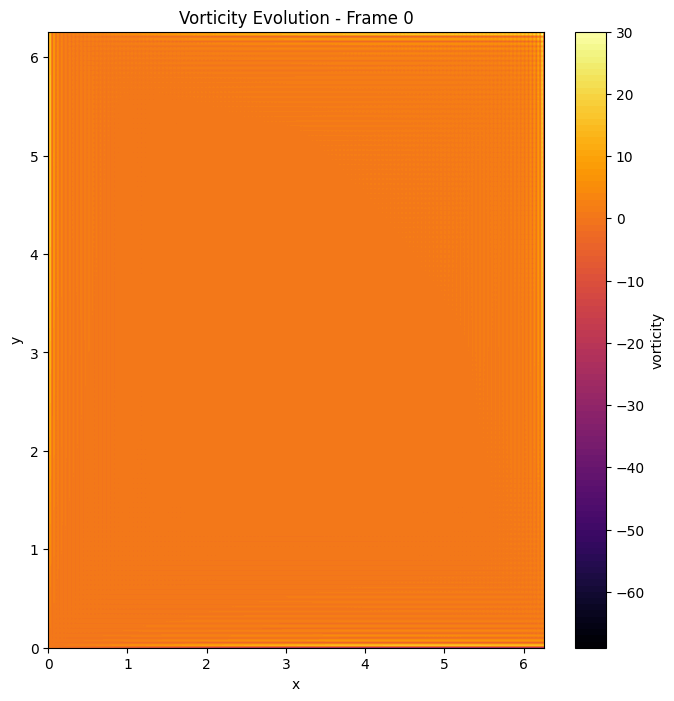

In [22]:
results = run_fourier_fluid_simulation(
    nx=256,
    ny=256,
    nu=0.01,
    dt=0.001,
    nt=1000,
    init="wave",
    amplitude=1.0,
    save_every=2,
    step_plot=10,
    interval=16.6,
    save_gif=True,
    gif_name="fourier_wave.gif",
)

Audit passed.
max |divergence| = 3.223e-14
initial energy   = 9.869407e+00
final energy     = 9.790963e+00
initial enstrophy= 9.869407e+00
final enstrophy  = 9.790963e+00


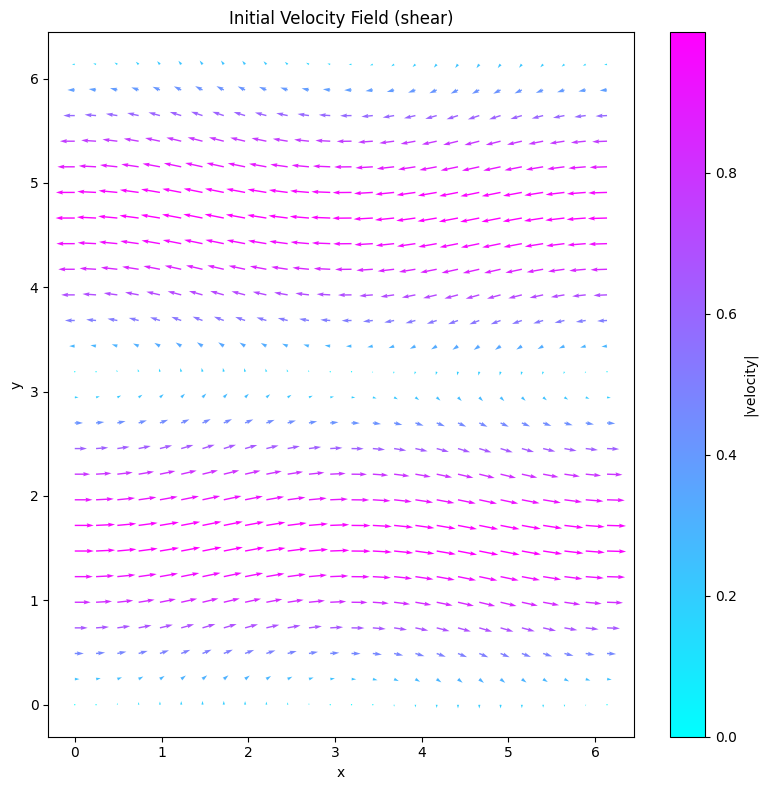

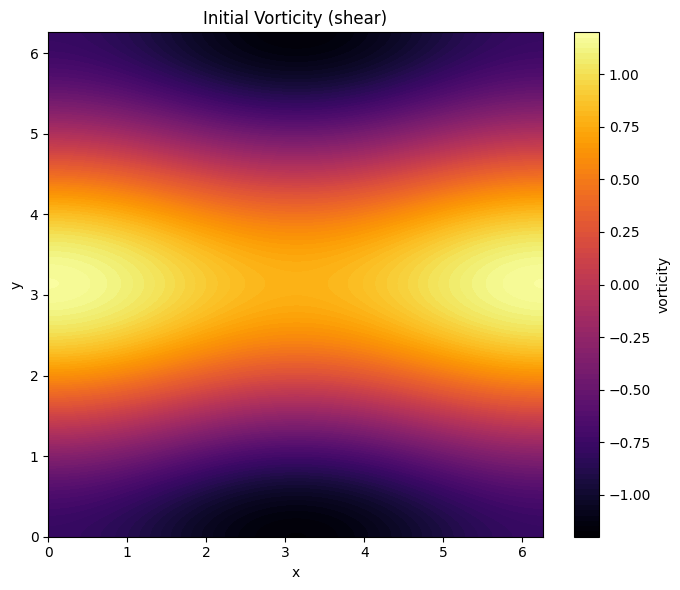

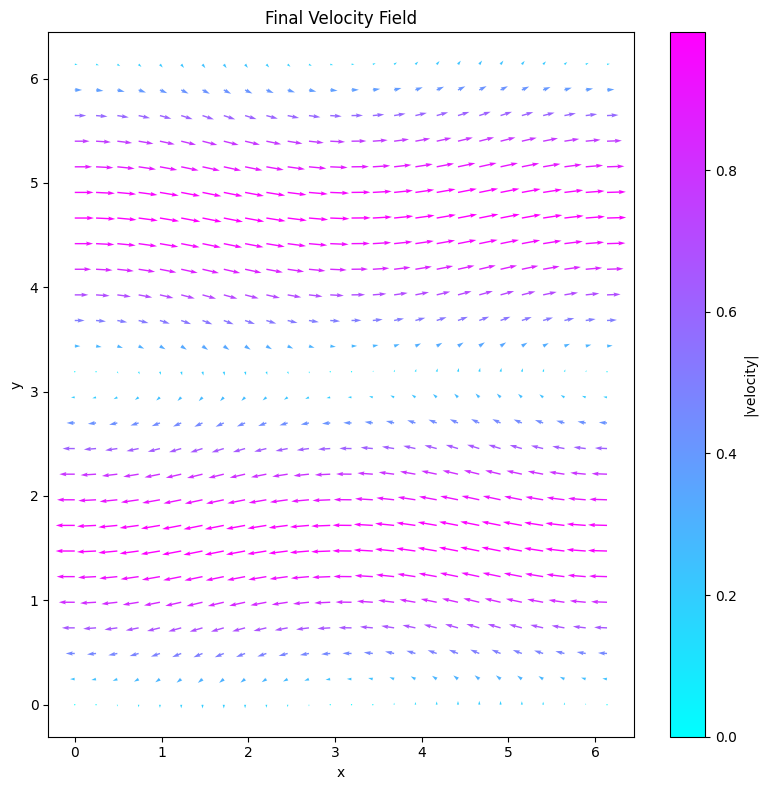

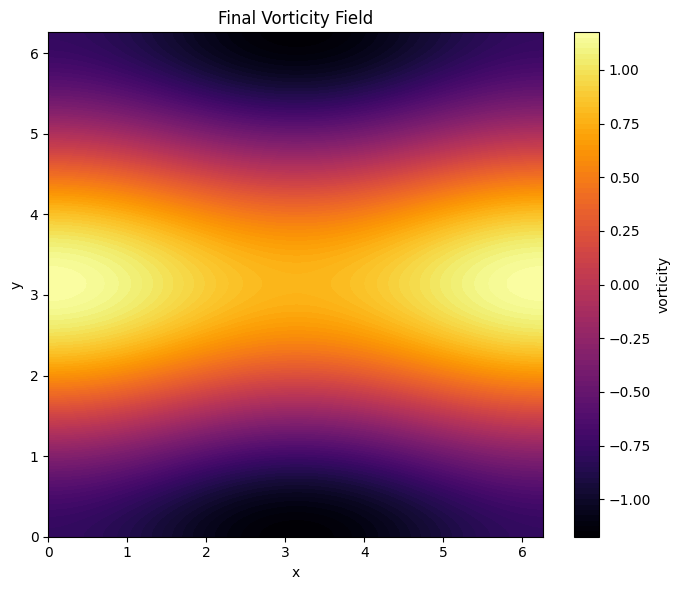

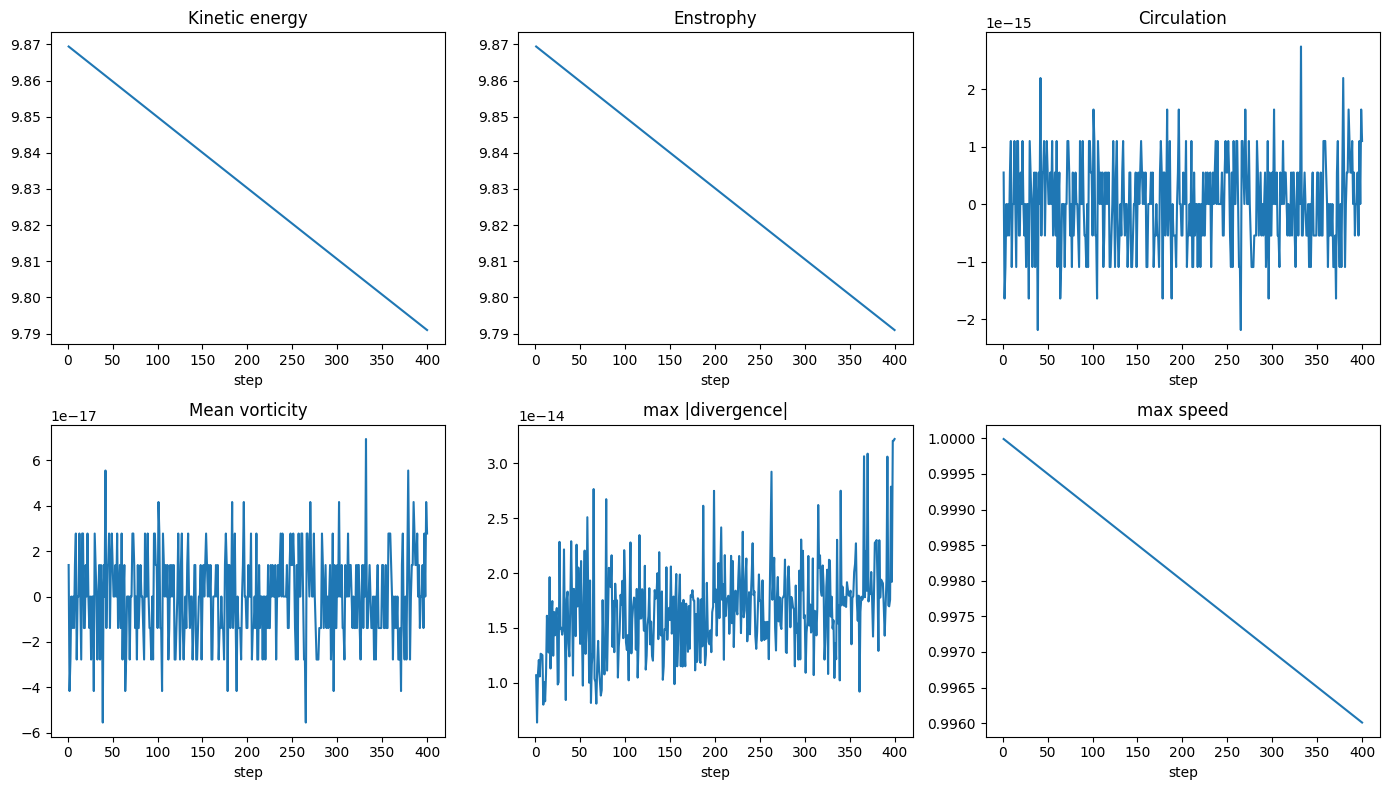

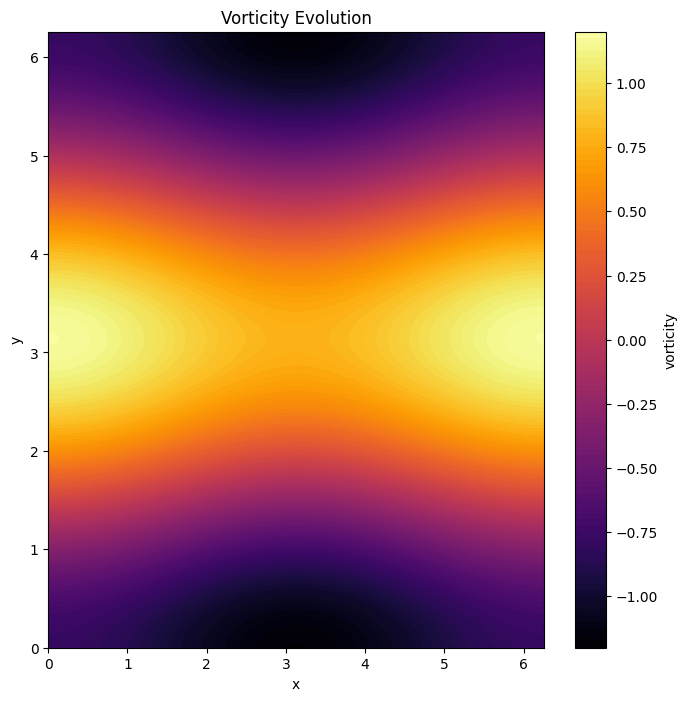

In [19]:
results_shear = run_fourier_fluid_simulation(
    nx=256,
    ny=256,
    nu=0.01,
    dt=0.001,
    nt=400,
    init="shear",
    amplitude=1.0,
    save_every=2,
    save_gif=False,
)

Audit passed.
max |divergence| = 2.095e-14
initial energy   = 9.868815e+00
final energy     = 9.558783e+00
initial enstrophy= 3.947526e+01
final enstrophy  = 3.823513e+01


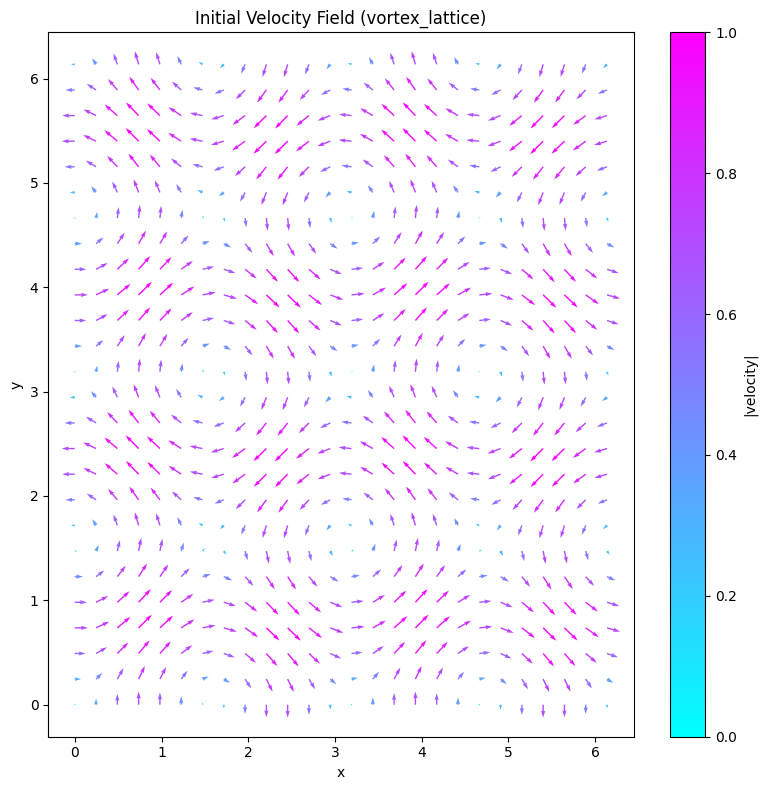

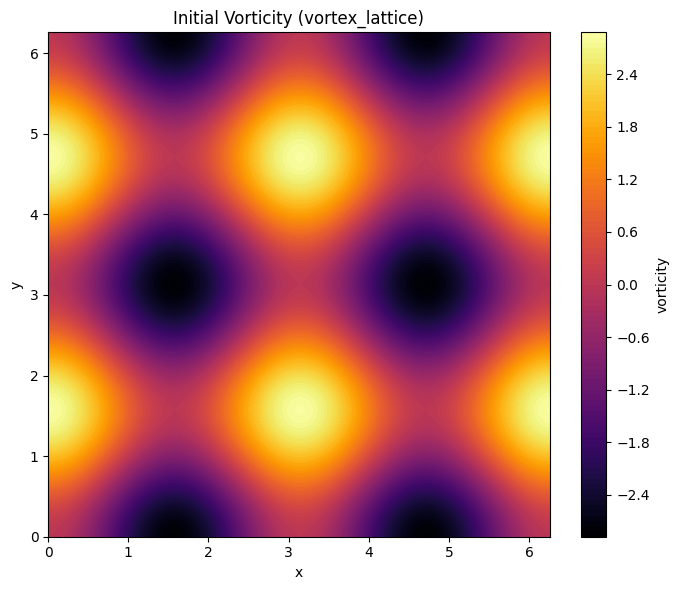

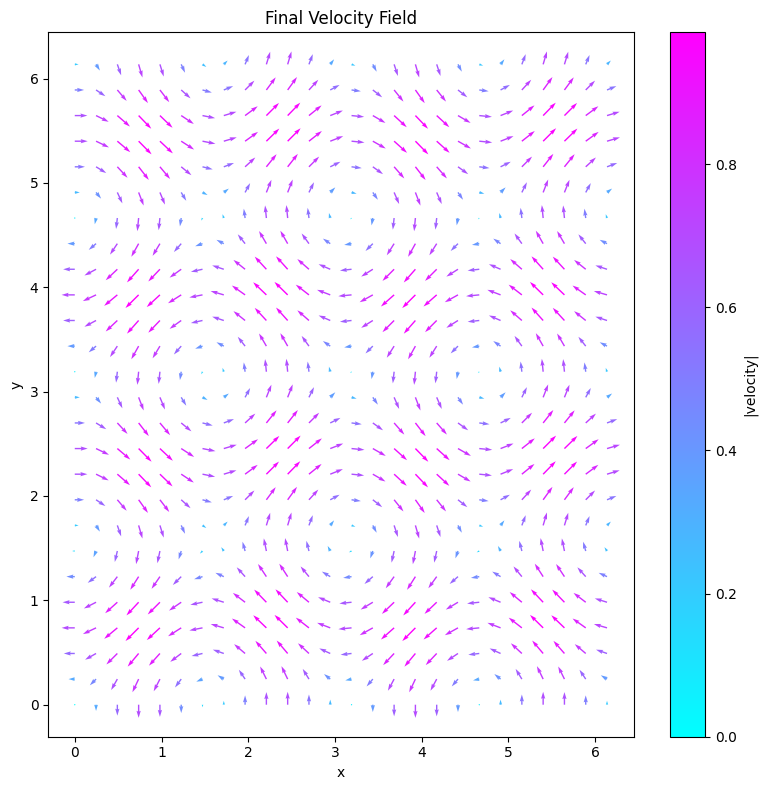

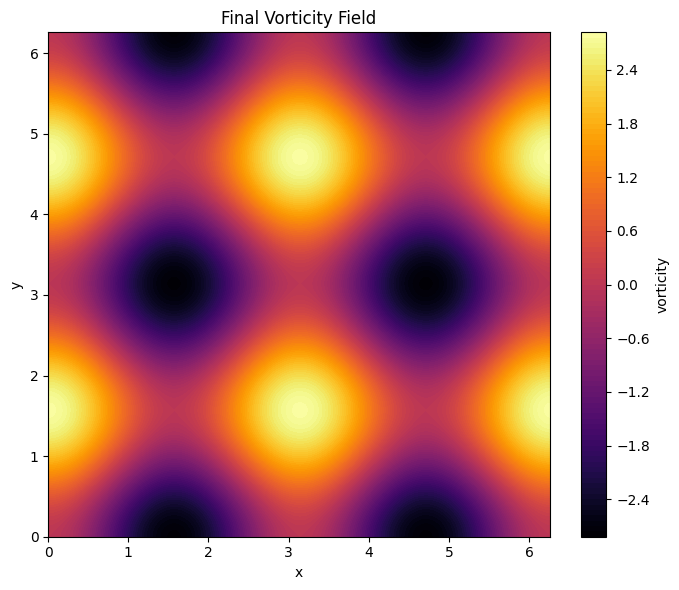

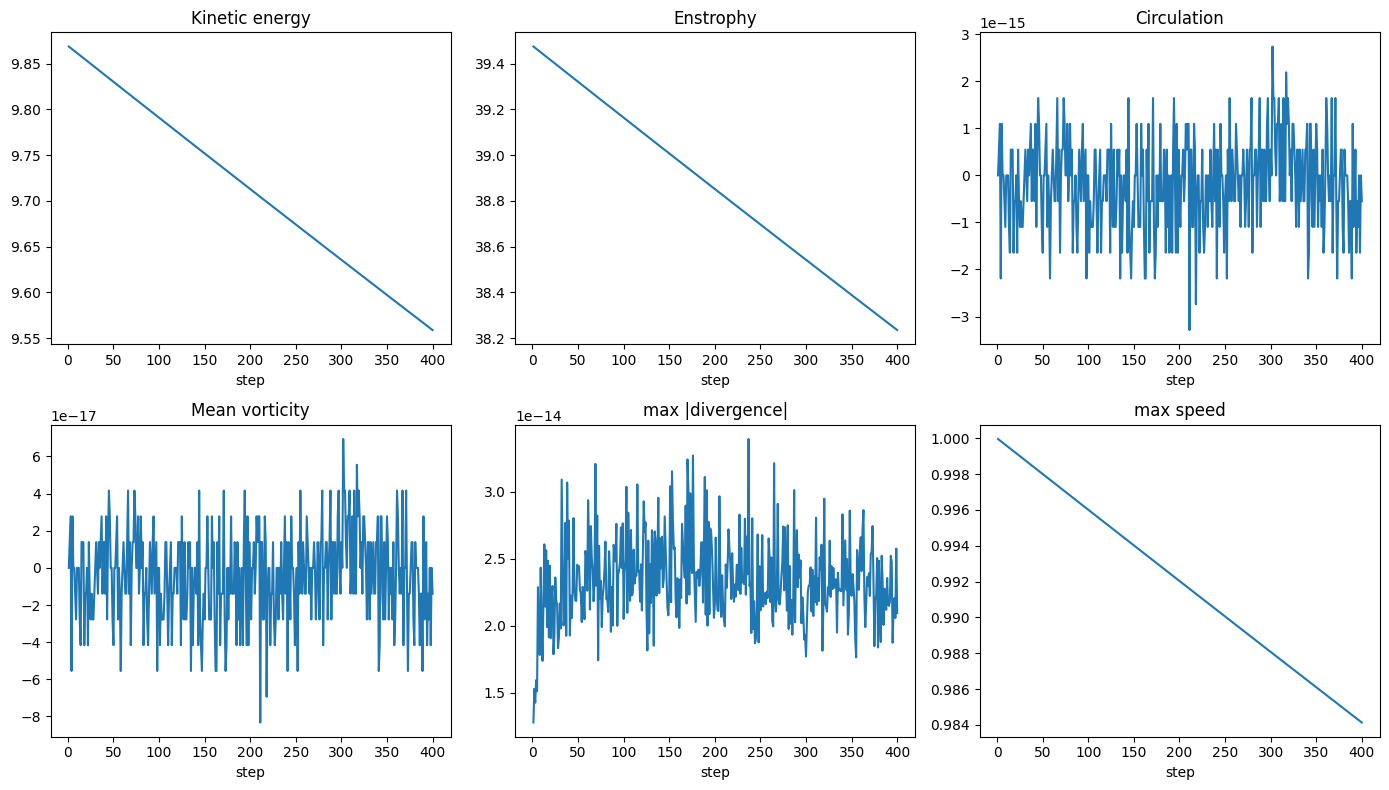

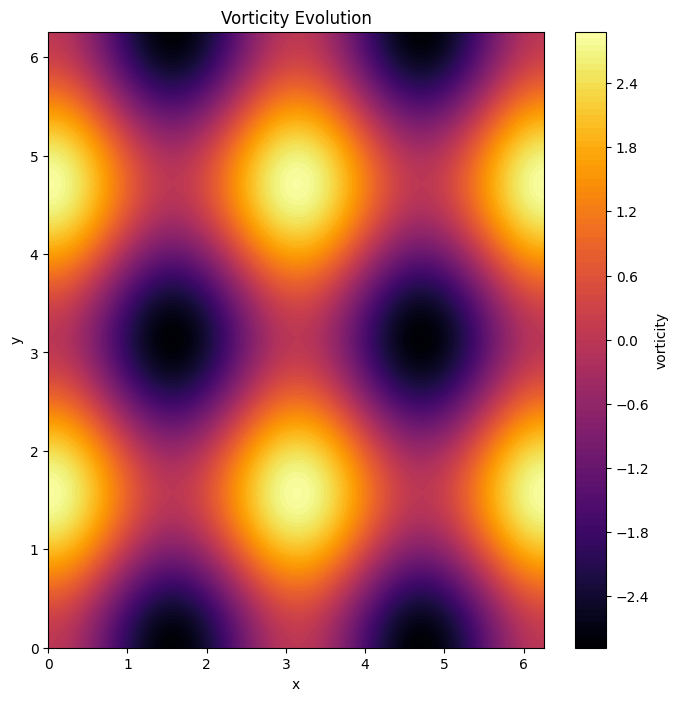

In [ ]:
results_vortex = run_fourier_fluid_simulation(
    nx=256,
    ny=256,
    nu=0.01,
    dt=0.001,
    nt=1000,
    init="vortex_lattice",
    amplitude=1.0,
    save_every=2,
    interval=16.6,
    save_gif=True,
    gif_name="multiple_vortices_fourier.gif"
)